Create persistent vector store for woman shoes

In [18]:
from llama_index.core.schema import ImageNode
from llama_index.core.response.notebook_utils import display_source_node, display_image_uris
from llama_index.embeddings.clip import ClipEmbedding
# from llama_index.embeddings.cohere import CohereEmbedding
from llama_index.core import VectorStoreIndex
from llama_index.vector_stores.chroma import ChromaVectorStore
from llama_index.core import StorageContext
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
from llama_index.vector_stores.chroma import ChromaVectorStore
from dotenv import load_dotenv
from tfg_chatbot.ingestion import load_documents
import chromadb
import os

In [2]:
_ = load_dotenv(".env")

In [4]:
embeder =ClipEmbedding()

In [5]:
# Create a persistent client
client = chromadb.PersistentClient(path="../app/women_index")

# Create a multimodal collection
collection = client.get_or_create_collection(
    name="multimodal_collection_women", 
    embedding_function=OpenCLIPEmbeddingFunction(),
    data_loader=ImageLoader(),
    )

In [6]:
image_documents, text_documents = load_documents('../data/women_txt/', '../data/women_images/')

In [7]:
print(f'Total Image Documents:', len(image_documents))
print(f'Total Text Documents:', len(image_documents))

Total Image Documents: 282
Total Text Documents: 282


In [8]:
image_documents[0].metadata

{'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\000893d0-18f1-4557-8d27-b9b3452829b1.jpg',
 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.jpg',
 'file_type': 'image/jpeg',
 'file_size': 358412,
 'creation_date': '2024-12-02',
 'last_modified_date': '2024-11-27'}

In [9]:
text_documents[0].text

'Name: LEATHER STRAPPY SANDALS\r\nDescription: High heel leather sandals with metallic effect. Thin straps. Round toe. Buckled ankle strap closure. \r\n\r\nHeel height: 3.9 inches (10 cm)\r\nPrice: 89.9\r\nCurrency: USD'

In [10]:
text_documents[0].metadata

{'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_txt\\000893d0-18f1-4557-8d27-b9b3452829b1.txt',
 'file_name': '000893d0-18f1-4557-8d27-b9b3452829b1.txt',
 'file_type': 'text/plain',
 'file_size': 208,
 'creation_date': '2024-12-02',
 'last_modified_date': '2024-12-02'}

In [11]:
# set up ChromaVectorStore and load in data with LlamaIndex 
vector_store = ChromaVectorStore(chroma_collection=collection)

In [12]:
# create storage context
storage_context = StorageContext.from_defaults(vector_store=vector_store)

### Create VectorStore Index 

In [14]:
# create index of documents
index = VectorStoreIndex.from_documents(
    documents = image_documents,
    storage_context=storage_context,
    embed_model = embeder
)

In [15]:
retriever = index.as_retriever(similarity_top_k=3)

In [16]:
retrival_result = retriever.retrieve("Slide Sandal")
retrival_result

[NodeWithScore(node=ImageNode(id_='82fe0944-d2d9-4265-86c6-d5d93a32ea3f', embedding=None, metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_name': '196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_type': 'image/jpeg', 'file_size': 341829, 'creation_date': '2024-12-02', 'last_modified_date': '2024-11-27'}, excluded_embed_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], excluded_llm_metadata_keys=['file_name', 'file_type', 'file_size', 'creation_date', 'last_modified_date', 'last_accessed_date'], relationships={<NodeRelationship.SOURCE: '1'>: RelatedNodeInfo(node_id='1b6f42ed-748b-4f4b-9457-141c8feef294', node_type='4', metadata={'file_path': 'd:\\workspace\\proyecto_tfg\\tfg-chatbot\\notebooks\\..\\data\\women_images\\196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_name': '196bfc19-7bb7-402b-a34f-9cb904cebc42.jpg', 'file_

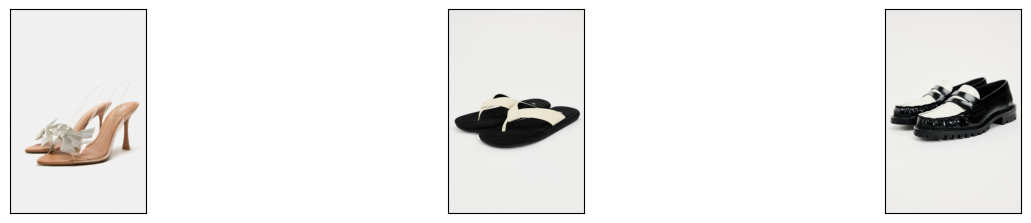

In [20]:
MAX_RES = 3 
cnt = 0
image_results = []
for r in retrival_result:
    if isinstance(r.node, ImageNode):
        image_results.append(r.node.metadata['file_path'])
    else:
        if cnt < MAX_RES:
            display_source_node(r)
        cnt += 1

display_image_uris(image_results, [3,3])

In [ ]:
# Define the sentence splitter
node_parser = SentenceSplitter.from_defaults()
image_nodes = node_parser.get_nodes_from_documents(image_documents)
text_nodes = node_parser.get_nodes_from_documents(text_documents)

    # Create multimodal index
    index = MultiModalVectorStoreIndex(
    nodes = image_nodes + text_nodes,
    image_embed_model=image_embed_model,
    embed_model = embed_model
    )